# Análise Exploratória dos dados

In [201]:
%%capture
!pip install xgboost catboost scikit-learn matplotlib seaborn pandas numpy

In [202]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.feature_selection import RFECV
from sklearn.model_selection import KFold
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from google.colab import drive
import seaborn as sns
import pandas as pd
import numpy as np
import os

In [203]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [204]:
base_dir = '/content/drive/MyDrive/supervised-learning-studies/projeto'
file_path = os.path.join(base_dir, 'BD_filerCalcario_versao_1.xlsx')
file = pd.ExcelFile(file_path)
print(file.sheet_names)

['BD_ML_Resis', 'BD_ML_Slump', 'Dicionario_Variaveis']


In [205]:
df_slump = file.parse('BD_ML_Slump')
df_slump.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Cimento_kg_m3                106 non-null    float64
 1   Filer_Calcario_kg_m3         106 non-null    float64
 2   Agua_kg_m3                   106 non-null    float64
 3   Agregado_Miudo_Total_kg_m3   106 non-null    float64
 4   Agregado_Graudo_Total_kg_m3  106 non-null    float64
 5   Superplastificante_kg_m3     102 non-null    float64
 6   Relacao_Agua_Cimento         106 non-null    float64
 7   Relacao_Agua_Aglomerante     106 non-null    float64
 8   Metodo_Emp_Cod               106 non-null    int64  
 9   Usa_SP                       106 non-null    int64  
 10  Classe_Cim_OpA               106 non-null    int64  
 11  Filer_D50_um                 50 non-null     float64
 12  D_Max                        82 non-null     float64
 13  Slump_mm            

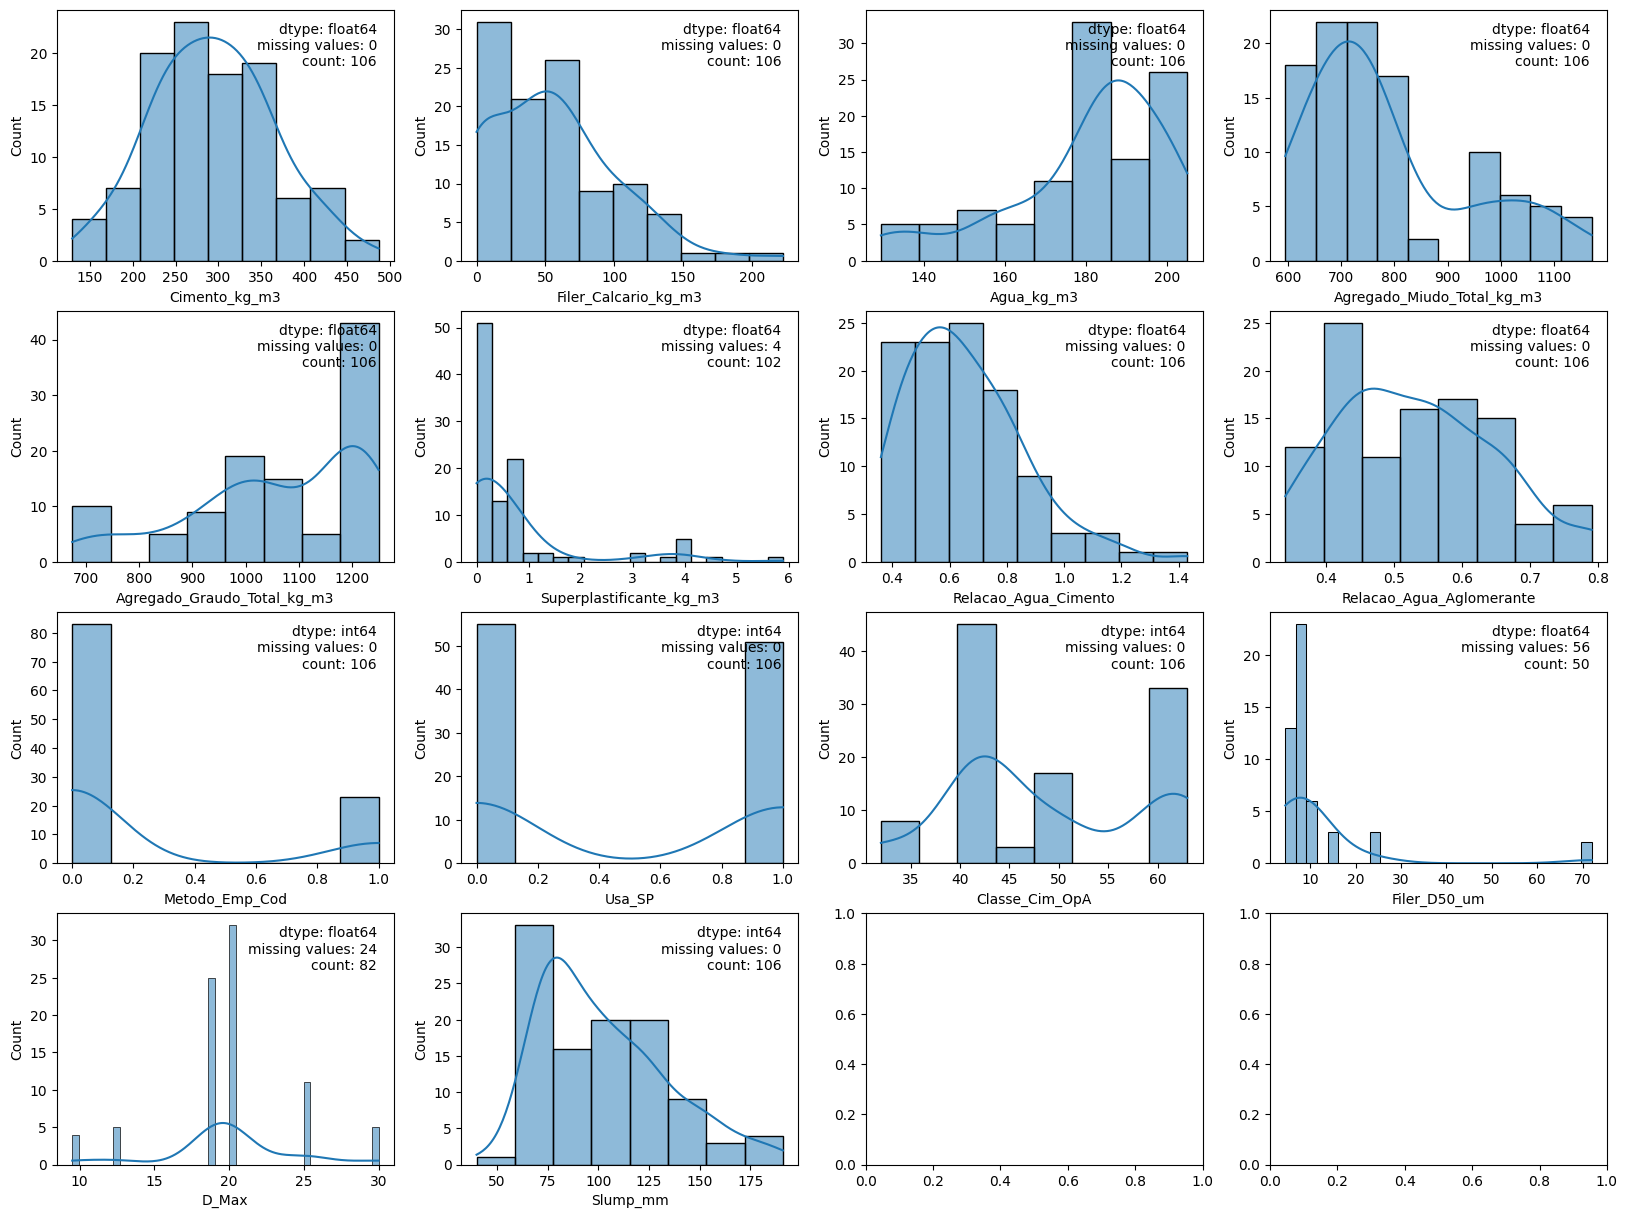

In [206]:
columns = df_slump.columns
figure, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 15))

for i, column in enumerate(columns):
    row = i // 4
    col = i % 4

    text = (f"dtype: {df_slump[column].dtype}\n"
            f"missing values: {df_slump[column].isnull().sum()}\n"
            f"count: {df_slump[column].count()}")
    axes[row][col].text(0.95, 0.95, text, transform=axes[row][col].transAxes,
                        verticalalignment='top', horizontalalignment='right')
    sns.histplot(df_slump[column], ax=axes[row][col], kde=True)

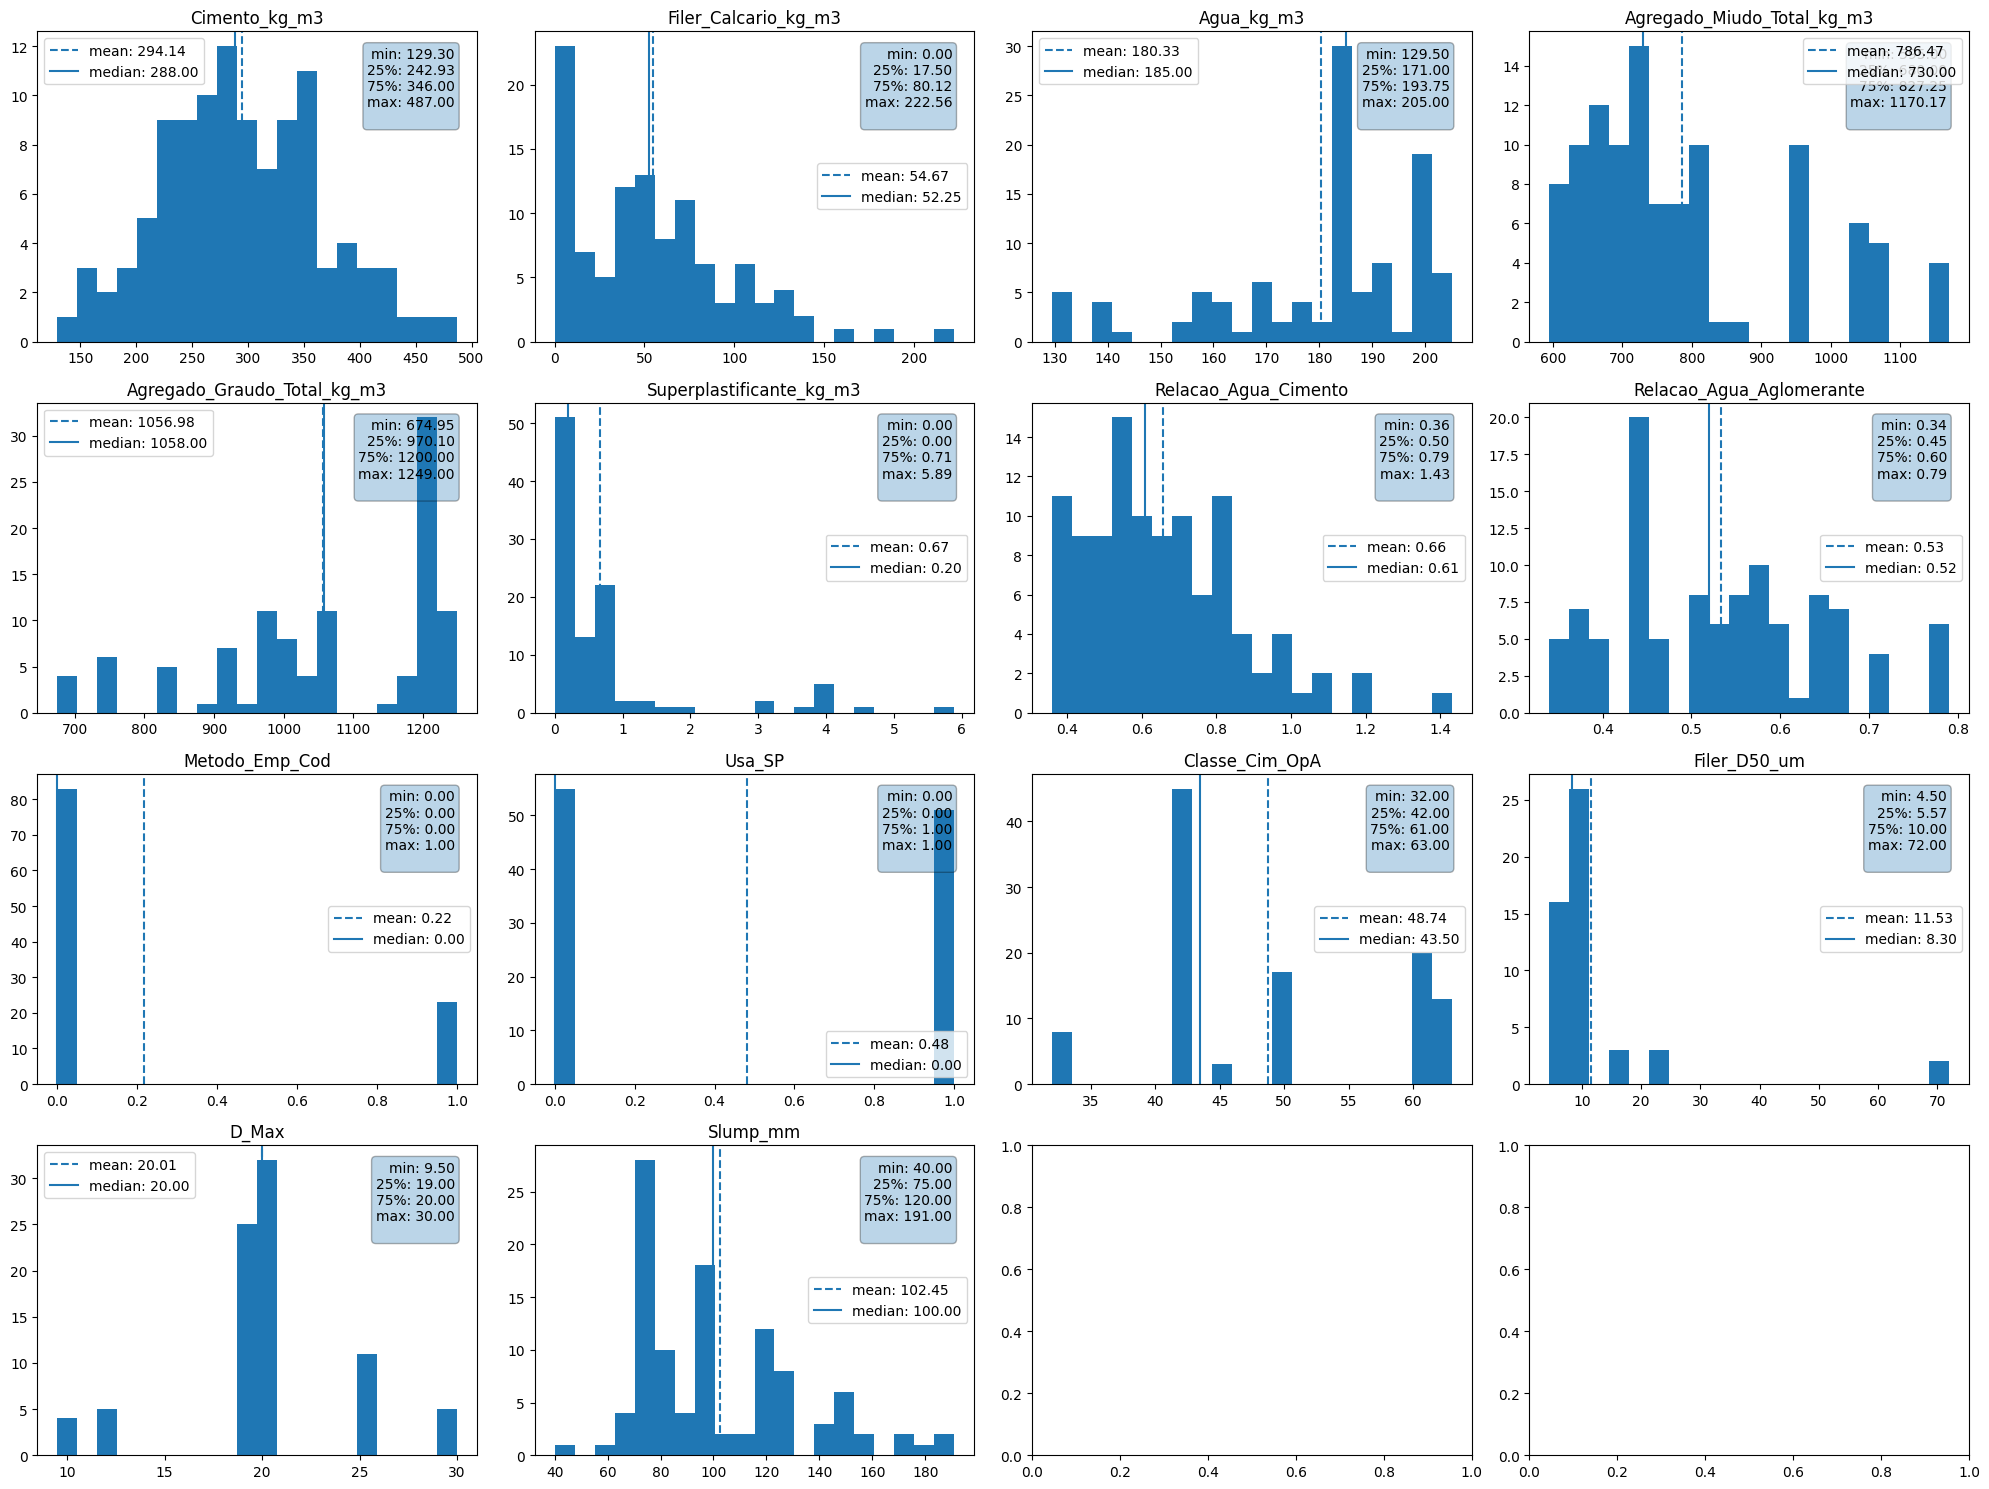

In [207]:
figure, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 15))

for i, column in enumerate(columns):
    ax = axes[i // 4, i % 4]
    data = df_slump[column]

    ax.set_title(column)
    ax.hist(data, bins=20)
    
    stats = data.describe()
    
    # Linhas de referência
    ax.axvline(stats['mean'], linestyle='--', label=f"mean: {stats['mean']:.2f}")
    ax.axvline(stats['50%'], linestyle='-', label=f"median: {stats['50%']:.2f}")
    
    # Texto com resumo
    text = (
        f"min: {stats['min']:.2f}\n"
        f"25%: {stats['25%']:.2f}\n"
        f"75%: {stats['75%']:.2f}\n"
        f"max: {stats['max']:.2f}\n"
    )
    
    ax.text(
        0.95, 0.95, text,
        transform=ax.transAxes,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle="round", alpha=0.3)
    )
    
    ax.legend()

plt.tight_layout()
plt.show()

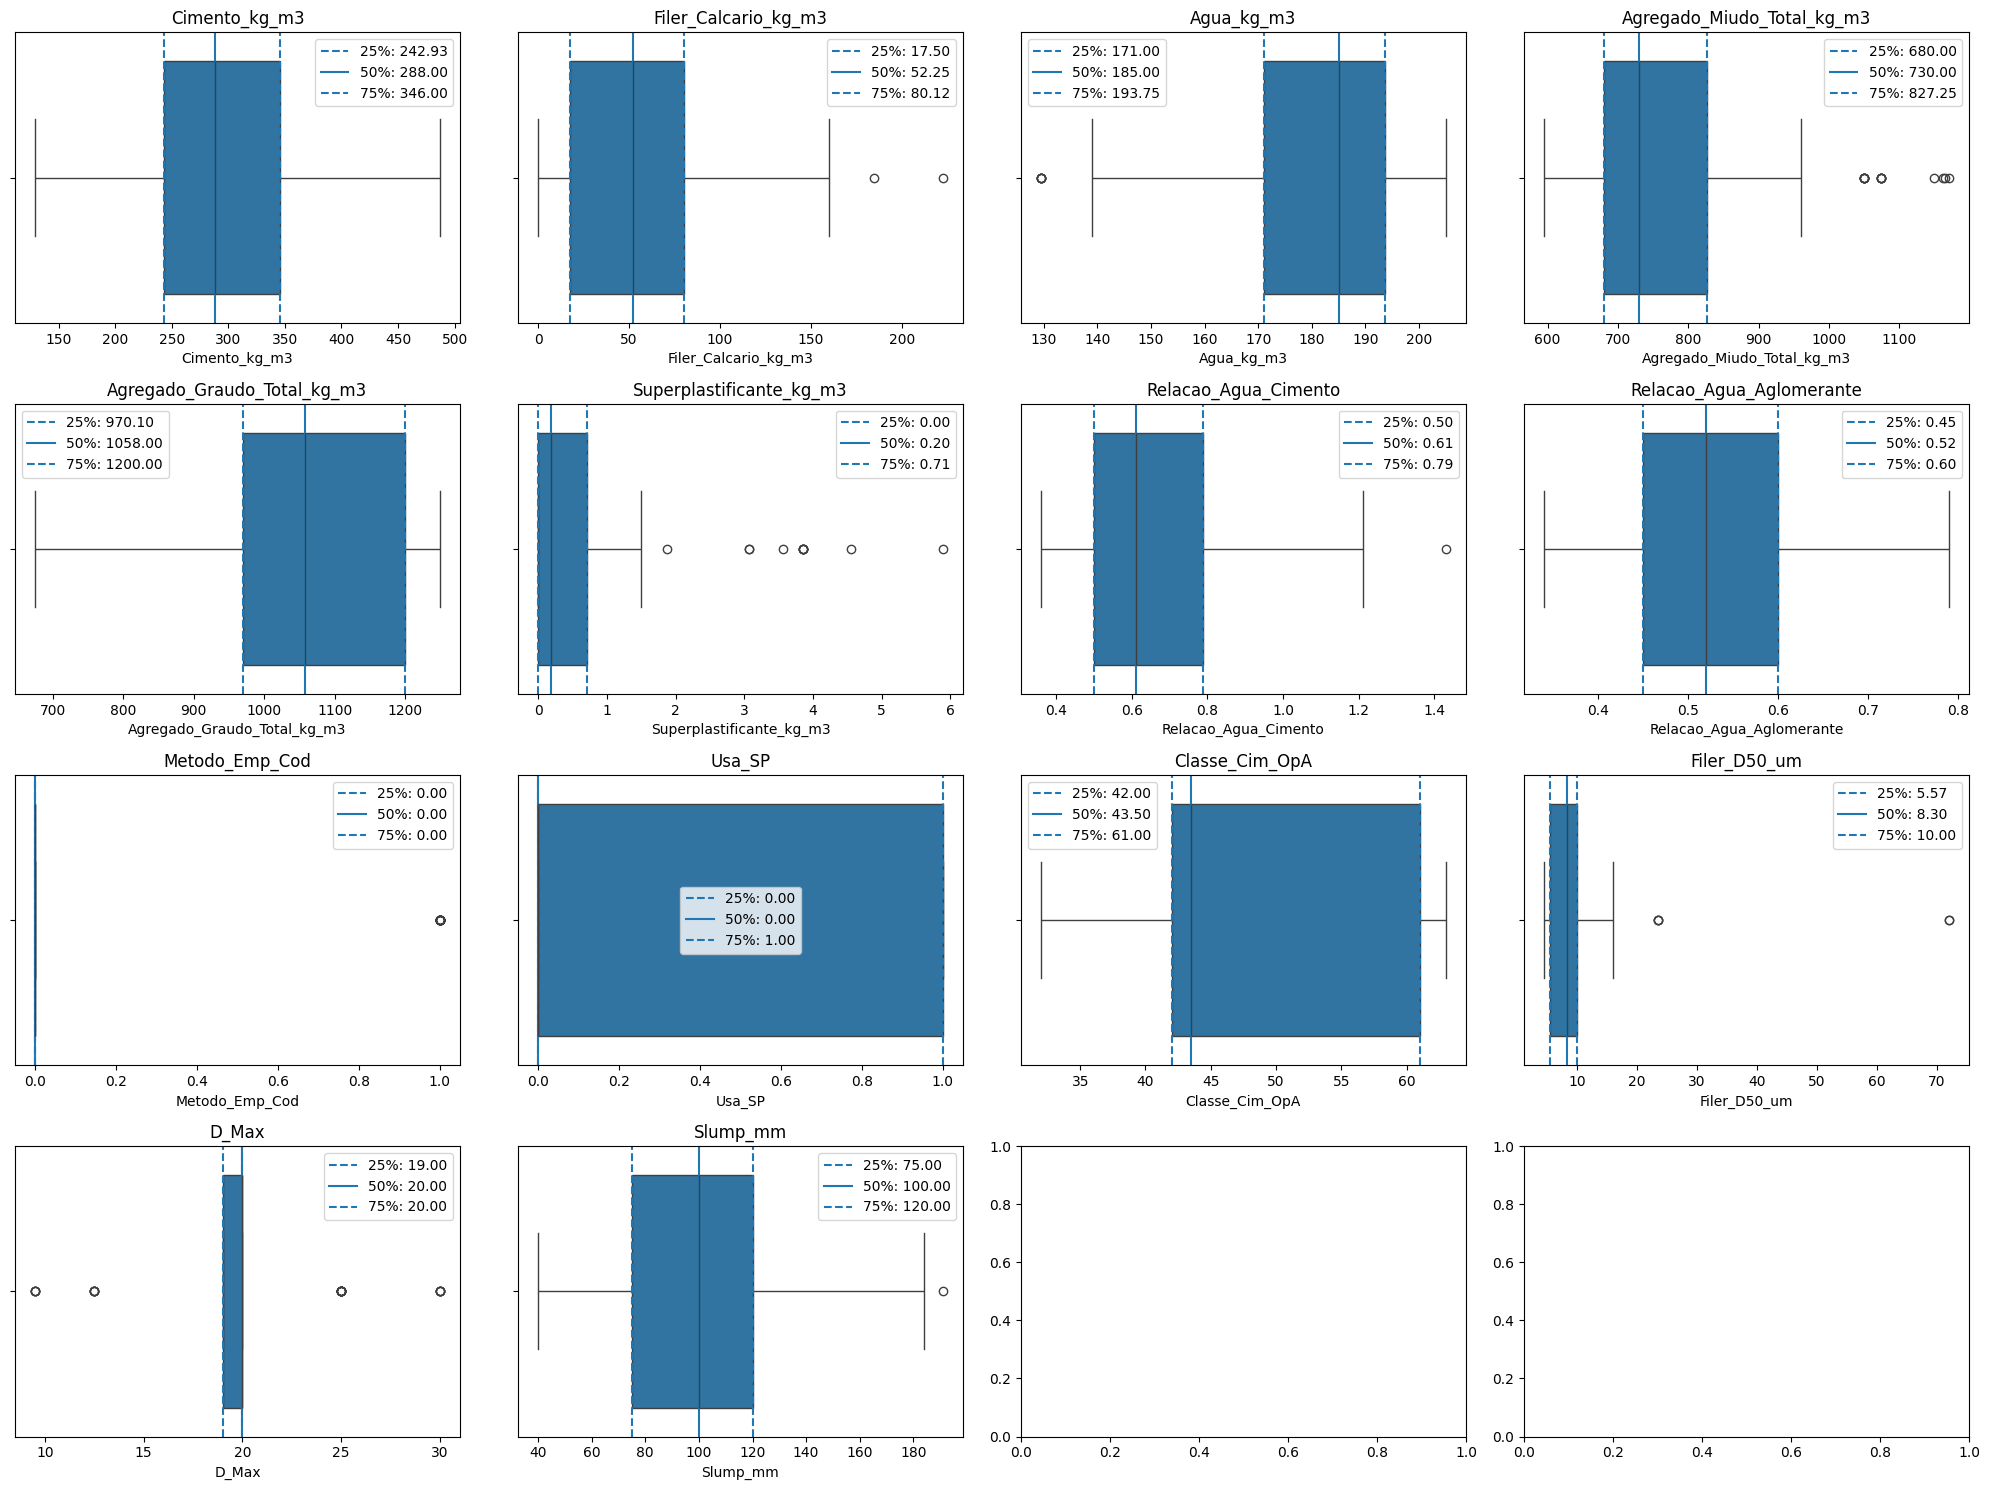

In [208]:
figure, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 15))

for i, column in enumerate(columns):
    ax = axes[i // 4, i % 4]
    data = df_slump[column]

    ax.set_title(column)
    sns.boxplot(x=data, ax=ax)
    
    stats = data.describe()

    # Linhas de referência
    ax.axvline(stats['25%'], linestyle='--', label=f"25%: {stats['25%']:.2f}")
    ax.axvline(stats['50%'], linestyle='-', label=f"50%: {stats['50%']:.2f}")
    ax.axvline(stats['75%'], linestyle='--', label=f"75%: {stats['75%']:.2f}")
    ax.legend()

plt.tight_layout()
plt.show()

In [209]:
# ==========================================
# CONSTANTES FÍSICAS
# ==========================================
DENSIDADE_CIMENTO = 3150
DENSIDADE_AGUA = 1000
DENSIDADE_FILER = 2700
DENSIDADE_AREIA = 2650
DENSIDADE_BRITA = 2700
DENSIDADE_SP = 1100

# Parâmetros calibráveis (ANTES eram "hardcoded")
K_AGUA_CIMENTO = 0.22
K_AGUA_FILER = 0.10
K_EQUIV_SP = 15.0
VOID_RATIO_AGREGADOS = 0.35

In [210]:
EPS = np.finfo(float).eps

# ==========================================
# 1. TRATAMENTO DE DADOS
# ==========================================
df_slump['Superplastificante_kg_m3'] = df_slump['Superplastificante_kg_m3'].fillna(0)
df_slump.drop(['Filer_D50_um'], axis=1, inplace=True, errors='ignore')
df_slump['D_Max'] = df_slump['D_Max'].fillna(df_slump['D_Max'].median())

# ==========================================
# 2. CONVERSÃO MASSA → VOLUME (m³/m³)
# ==========================================
df_slump['vol_cimento'] = pd.to_numeric(df_slump['Cimento_kg_m3'], errors='coerce') / DENSIDADE_CIMENTO
df_slump['vol_filer'] = pd.to_numeric(df_slump['Filer_Calcario_kg_m3'], errors='coerce') / DENSIDADE_FILER
df_slump['vol_agua'] = pd.to_numeric(df_slump['Agua_kg_m3'], errors='coerce') / DENSIDADE_AGUA
df_slump['vol_areia'] = pd.to_numeric(df_slump['Agregado_Miudo_Total_kg_m3'], errors='coerce') / DENSIDADE_AREIA
df_slump['vol_brita'] = pd.to_numeric(df_slump['Agregado_Graudo_Total_kg_m3'], errors='coerce') / DENSIDADE_BRITA
df_slump['vol_sp'] = pd.to_numeric(df_slump['Superplastificante_kg_m3'], errors='coerce') / DENSIDADE_SP

# ==========================================
# 3. FECHAMENTO VOLUMÉTRICO
# ==========================================
volume_materiais = (
    df_slump['vol_cimento'] + df_slump['vol_filer'] + df_slump['vol_agua'] +
    df_slump['vol_areia'] + df_slump['vol_brita'] + df_slump['vol_sp']
)

df_slump['vol_ar_aprisionado'] = (1.0 - volume_materiais).clip(lower=0)

# ==========================================
# 4. AGRUPAMENTOS
# ==========================================
df_slump['vol_aglomerante'] = df_slump['vol_cimento'] + df_slump['vol_filer']
df_slump['vol_agregados'] = df_slump['vol_areia'] + df_slump['vol_brita']

df_slump['vol_pasta'] = (
    df_slump['vol_aglomerante'] +
    df_slump['vol_agua'] +
    df_slump['vol_sp'] +
    df_slump['vol_ar_aprisionado']
)

df_slump['vol_argamassa'] = df_slump['vol_pasta'] + df_slump['vol_areia']

# 🔧 Correção: evitar propagação de erro numérico
df_slump['vol_total'] = 1.0

# ==========================================
# 5. ÁGUA EFETIVA
# ==========================================
df_slump['massa_aglomerante_total'] = (
    df_slump['Cimento_kg_m3'] + df_slump['Filer_Calcario_kg_m3']
)

agua_adsorvida = (
    K_AGUA_CIMENTO * df_slump['Cimento_kg_m3'] +
    K_AGUA_FILER * df_slump['Filer_Calcario_kg_m3']
)

df_slump['vol_agua_livre'] = (
    (df_slump['Agua_kg_m3'] - agua_adsorvida).clip(lower=0)
) / DENSIDADE_AGUA

# ==========================================
# 6. FRAÇÕES
# ==========================================
df_slump['fracao_vol_pasta'] = df_slump['vol_pasta']
df_slump['fracao_vol_argamassa'] = df_slump['vol_argamassa']

# ==========================================
# 7. RELAÇÕES
# ==========================================
df_slump['agua_aglomerante_vol'] = df_slump['vol_agua'] / df_slump['vol_aglomerante'].clip(lower=EPS)

df_slump['relacao_areia_brita_vol'] = df_slump['vol_areia'] / df_slump['vol_brita'].clip(lower=EPS)

df_slump['fator_areia_agregado'] = df_slump['vol_areia'] / df_slump['vol_agregados'].clip(lower=EPS)

# 🔧 Correção: agora representa melhor pasta vs esqueleto granular
df_slump['teor_pasta_relativo'] = df_slump['vol_pasta'] / df_slump['vol_agregados'].clip(lower=EPS)

df_slump['filer_sobre_cimento_vol'] = df_slump['vol_filer'] / df_slump['vol_cimento'].clip(lower=EPS)

# ==========================================
# 8. LUBRIFICAÇÃO
# ==========================================
df_slump['agua_equivalente_vol'] = df_slump['vol_agua'] + K_EQUIV_SP * df_slump['vol_sp']

df_slump['indice_lubrificacao_global'] = (
    df_slump['agua_equivalente_vol'] / df_slump['vol_brita'].clip(lower=EPS)
)

# ==========================================
# 9. REOLOGIA
# ==========================================
df_slump['particle_crowding_index'] = (
    df_slump['vol_agregados'] / df_slump['vol_pasta'].clip(lower=EPS)
)

# 🔧 Correção: não pode ser negativo
df_slump['vol_pasta_livre'] = (
    df_slump['vol_pasta'] - VOID_RATIO_AGREGADOS * df_slump['vol_agregados']
).clip(lower=0)

# 🔧 Correção: área mais coerente fisicamente
df_slump['area_superficial_proxy'] = (
    df_slump['vol_areia'] / 0.2 +   # D_areia ~ 0.2 mm
    df_slump['vol_brita'] / df_slump['D_Max'].clip(lower=EPS)
)

df_slump['paste_film_thickness'] = (
    df_slump['vol_pasta_livre'] / df_slump['area_superficial_proxy'].clip(lower=EPS)
)

df_slump['rigidez_pasta'] = (
    df_slump['vol_aglomerante'] / df_slump['agua_equivalente_vol'].clip(lower=EPS)
)

df_slump['yield_stress_proxy'] = (
    df_slump['rigidez_pasta'] * df_slump['particle_crowding_index']
)

# ==========================================
# 10. SEGREGAÇÃO
# ==========================================
df_slump['agua_sobre_areia'] = df_slump['vol_agua'] / df_slump['vol_areia'].clip(lower=EPS)

df_slump['potencial_segregacao'] = (
    df_slump['agua_sobre_areia'] / df_slump['teor_pasta_relativo'].clip(lower=EPS)
)

# ==========================================
# 11. FEATURES FINAIS
# ==========================================
df_slump['fluido_lubrificante_total'] = (
    df_slump['vol_agua'] + df_slump['vol_ar_aprisionado']
)

df_slump['vol_finos_reconstruido'] = (
    df_slump['teor_pasta_relativo'] * df_slump['vol_agregados']
)

df_slump['fator_agua_finos'] = (
    df_slump['vol_agua'] / df_slump['vol_finos_reconstruido'].clip(lower=EPS)
)

df_slump['lubrificacao_efetiva'] = (
    df_slump['indice_lubrificacao_global'] /
    (1 + df_slump['potencial_segregacao'])
)

In [211]:
ALVO = 'Slump_mm' 

whitelist_features = [
    'Usa_SP',
    'D_Max',
    'fracao_vol_pasta',
    'vol_ar_aprisionado',
    'rigidez_pasta',
    'yield_stress_proxy',
    'lubrificacao_efetiva'
]

# 1. Correlação
corr_matrix = df_slump.corr(method='spearman').abs()
corr_com_alvo = corr_matrix[ALVO].drop(ALVO)

limite_colinearidade = 0.90
features_para_remover = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        col_i = corr_matrix.columns[i]
        col_j = corr_matrix.columns[j]

        if col_i == ALVO or col_j == ALVO:
            continue

        if corr_matrix.iloc[i, j] > limite_colinearidade:

            if col_i in whitelist_features and col_j in whitelist_features:
                continue
            elif col_i in whitelist_features:
                features_para_remover.add(col_j)
                continue
            elif col_j in whitelist_features:
                features_para_remover.add(col_i)
                continue

            # lógica original
            if corr_com_alvo[col_i] > corr_com_alvo[col_j]:
                features_para_remover.add(col_j)
            else:
                features_para_remover.add(col_i)

print(f"Features removidas por colinearidade: {features_para_remover}")

df_filtrado = df_slump.drop(columns=features_para_remover)

Features removidas por colinearidade: {'area_superficial_proxy', 'vol_areia', 'vol_agregados', 'vol_cimento', 'vol_pasta_livre', 'vol_filer', 'vol_sp', 'Filer_Calcario_kg_m3', 'Relacao_Agua_Aglomerante', 'massa_aglomerante_total', 'fator_areia_agregado', 'relacao_areia_brita_vol', 'vol_brita', 'fracao_vol_argamassa', 'potencial_segregacao', 'Superplastificante_kg_m3', 'Relacao_Agua_Cimento', 'agua_sobre_areia', 'vol_finos_reconstruido', 'vol_pasta', 'Agregado_Miudo_Total_kg_m3', 'particle_crowding_index', 'vol_agua_livre', 'Agregado_Graudo_Total_kg_m3', 'teor_pasta_relativo', 'vol_agua', 'paste_film_thickness'}


In [212]:
df_filtrado.columns

Index(['Cimento_kg_m3', 'Agua_kg_m3', 'Metodo_Emp_Cod', 'Usa_SP',
       'Classe_Cim_OpA', 'D_Max', 'Slump_mm', 'vol_ar_aprisionado',
       'vol_aglomerante', 'vol_argamassa', 'vol_total', 'fracao_vol_pasta',
       'agua_aglomerante_vol', 'filer_sobre_cimento_vol',
       'agua_equivalente_vol', 'indice_lubrificacao_global', 'rigidez_pasta',
       'yield_stress_proxy', 'fluido_lubrificante_total', 'fator_agua_finos',
       'lubrificacao_efetiva'],
      dtype='object')

In [213]:
df_filtrado.corr(method='spearman')['Slump_mm'].abs().sort_values(ascending=False)

,Slump_mm
Slump_mm,1.000000
vol_argamassa,0.424470
lubrificacao_efetiva,0.373308
fluido_lubrificante_total,0.337521
fracao_vol_pasta,0.319491
Usa_SP,0.318369
indice_lubrificacao_global,0.287334
Metodo_Emp_Cod,0.257278
Classe_Cim_OpA,0.253735
vol_ar_aprisionado,0.166077


In [214]:
# 1. Preparando os dados
X = df_filtrado.drop(columns=[ALVO]).copy()
y = df_filtrado[ALVO]

nome_modelo = "CatBoost"

# 2. Dicionário com os seus competidores (O CatBoost precisa do verbose=False para não poluir a tela)
modelos = {
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=False, thread_count=-1),
    "HGBR": GradientBoostingRegressor(random_state=42) # Usado no lugar do HGBR
}

if nome_modelo == "HGBR":
    X.fillna(X.mean(), inplace=True)  # Preenche valores faltantes com a média (HGBR não lida bem com NaNs)

# Dicionário para guardar os resultados de cada modelo
resultados_selecao = {}

# 3. O Loop de Automação
estimador = modelos[nome_modelo]
print(f"⏳ Rodando RFECV para o modelo: {nome_modelo}...")

seletor_rfecv = RFECV(
    estimator=estimador, 
    step=1, 
    cv=KFold(n_splits=3, shuffle=True, random_state=42),
    scoring='neg_root_mean_squared_error',
    min_features_to_select=5,
    n_jobs=-1
)

# Treina o seletor
seletor_rfecv.fit(X, y)

# Salva as features que sobreviveram para este modelo
features_sobreviventes = list(X.columns[seletor_rfecv.support_])

resultados_selecao[nome_modelo] = {
    "Qtd_Otimizada": seletor_rfecv.n_features_,
    "Features_Selecionadas": features_sobreviventes
}

print(f"✅ {nome_modelo} finalizado! Elegeu {seletor_rfecv.n_features_} features.\n")
df_final = df_filtrado[resultados_selecao[nome_modelo]["Features_Selecionadas"] + [ALVO]]


⏳ Rodando RFECV para o modelo: CatBoost...
✅ CatBoost finalizado! Elegeu 19 features.



In [215]:
features_sobreviventes

['Cimento_kg_m3',
 'Agua_kg_m3',
 'Metodo_Emp_Cod',
 'Usa_SP',
 'Classe_Cim_OpA',
 'D_Max',
 'vol_ar_aprisionado',
 'vol_aglomerante',
 'vol_argamassa',
 'fracao_vol_pasta',
 'agua_aglomerante_vol',
 'filer_sobre_cimento_vol',
 'agua_equivalente_vol',
 'indice_lubrificacao_global',
 'rigidez_pasta',
 'yield_stress_proxy',
 'fluido_lubrificante_total',
 'fator_agua_finos',
 'lubrificacao_efetiva']

In [216]:
columns = df_final.columns

outliers_idx = {}
for column in columns:
    if column == 'bins' or column == 'Slump_mm':
        continue
    data = df_final[column]
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_idx[column] = data[(data < lower_bound) | (data > upper_bound)].index.tolist()

for column, idx in sorted(outliers_idx.items(), key=lambda x: len(x[1]), reverse=True):
    print(f"{column}: {len(idx)} outliers")

D_Max: 25 outliers
Metodo_Emp_Cod: 23 outliers
indice_lubrificacao_global: 15 outliers
agua_equivalente_vol: 12 outliers
vol_aglomerante: 10 outliers
filer_sobre_cimento_vol: 6 outliers
Agua_kg_m3: 5 outliers
vol_ar_aprisionado: 5 outliers
lubrificacao_efetiva: 4 outliers
fator_agua_finos: 1 outliers
Cimento_kg_m3: 0 outliers
Usa_SP: 0 outliers
Classe_Cim_OpA: 0 outliers
vol_argamassa: 0 outliers
fracao_vol_pasta: 0 outliers
agua_aglomerante_vol: 0 outliers
rigidez_pasta: 0 outliers
yield_stress_proxy: 0 outliers
fluido_lubrificante_total: 0 outliers


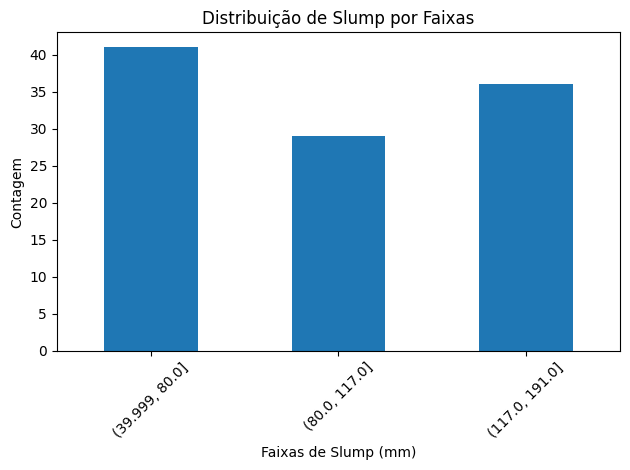

In [217]:
df_final['bins'] = pd.qcut(df_final['Slump_mm'], q=3, duplicates='drop')
df_final['bins'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribuição de Slump por Faixas')
plt.xlabel('Faixas de Slump (mm)')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [218]:
df_final.to_pickle(os.path.join(base_dir + "/slump", f'df_slump_{nome_modelo}.pkl'))